Generate a simulated data set

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP import load_data
import pandas as pd
from ISLP.models import (ModelSpec as MS,
summarize,
poly)
from sklearn.model_selection import train_test_split
from functools import partial
from sklearn.model_selection import \
(cross_validate,
KFold,
ShuffleSplit)
from sklearn.base import clone
from ISLP.models import sklearn_sm

In [5]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

n = 100; 
p = 2; 
$Y = X - 2X² + \varepsilon$

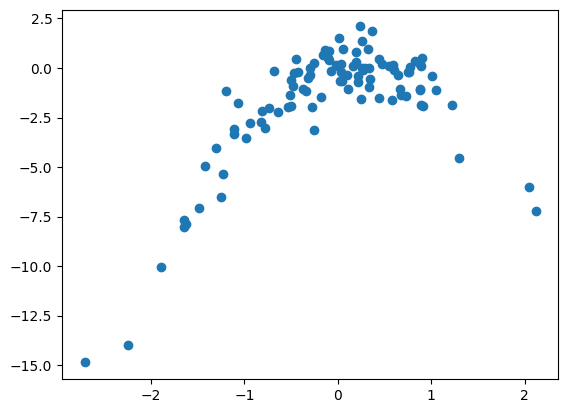

In [6]:
plt.scatter(x, y)
plt.show()

In [13]:
x_df = pd.DataFrame(x, columns=["X"])
x_df

,X
0,0.345584
1,0.821618
2,0.330437
3,-1.303157
4,0.905356
...,...
95,-2.250854
96,-0.138655
97,0.033000
98,-1.425349


In [16]:
def create_model(mm = MS(["X"])):
    X_train = mm.fit_transform(x_df)
    model = sm.OLS(y, X_train)
    results = model.fit()
    return results

In [24]:
def eval_model(mm = MS(["X"])):
    model = sklearn_sm(sm.OLS, mm)
    cv = cross_validate(model, x_df, y, cv=x.shape[0])
    return cv

In [45]:
cv_error = np.zeros(4)
M = sklearn_sm(sm.OLS)

for i,d in enumerate(range(1,5)):
    X = np.power.outer(x, np.arange(d + 1))
    
    model_fit = sm.OLS(y, X).fit()
    print(model_fit.summary())
    
    # Cross-validation
    m_cv = cross_validate(M, X, y, cv=x_df.shape[0])
    cv_error[i] = np.mean(m_cv["test_score"])
    
    print(f"\nLOOCV MSE: {cv_error[i]:.6f}")

cv_error

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     35.70
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           3.72e-08
Time:                        21:42:38   Log-Likelihood:                -209.26
No. Observations:                 100   AIC:                             422.5
Df Residuals:                      98   BIC:                             427.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1833      0.199     -5.960      0.0

array([4.25188287, 0.96399846, 0.99127119, 1.0181801 ])

(d) Repeat (c) using another random seed, and report your results.
Are your results the same as what you got in (c)? Why?

In [34]:
rng = np.random.default_rng(42)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

In [35]:
x_df = pd.DataFrame(x, columns=["X"])
x_df

,X
0,0.304717
1,-1.039984
2,0.750451
3,0.940565
4,-1.951035
...,...
95,-1.447112
96,-1.322700
97,-0.997247
98,0.399774


In [ ]:
cv_error = np.zeros(4)
M = sklearn_sm(sm.OLS)

for i,d in enumerate(range(1,5)):
    X = np.power.outer(x, np.arange(d + 1))
    
    model_fit = sm.OLS(y, X).fit()
    print(model_fit.summary())
    
    # Cross-validation
    m_cv = cross_validate(M, X, y, cv=x_df.shape[0])
    cv_error[i] = np.mean(m_cv["test_score"])
    
    print(f"\nLOOCV MSE: {cv_error[i]:.6f}")

cv_error

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                     35.70
Date:                Sun, 16 Nov 2025   Prob (F-statistic):           3.72e-08
Time:                        21:31:23   Log-Likelihood:                -209.26
No. Observations:                 100   AIC:                             422.5
Df Residuals:                      98   BIC:                             427.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1833      0.199     -5.960      0.0

array([4.25188287, 0.96399846, 0.99127119, 1.0181801 ])

No it does not give the same results, since it's based on a completely different dataset. But both show, that degree 2 is the best one for both datasets!

Which of the models in (c) had the smallest LOOCV error? Is
this what you expected? Explain your answer.

Yes, this is to be expected, since the simulated y data is created by using a 2nd-degree polynomial of X

Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using
least squares. Do these results agree with the conclusions drawn
based on the cross-validation results?

Yes, cause P of x and x² is 0.00, while x³ and x⁴ are above 0.05, therefore agreeing with the conclusions drawn based on LOOCV results